Best K = 16

Accuracy : 0.5193578847969783

Classification Report

              precision    recall  f1-score   support

       False       0.51      0.60      0.55       518
        True       0.54      0.45      0.49       541

    accuracy                           0.52      1059
   macro avg       0.52      0.52      0.52      1059
weighted avg       0.52      0.52      0.52      1059


Confusion Matrix

[[309 209]
 [300 241]]


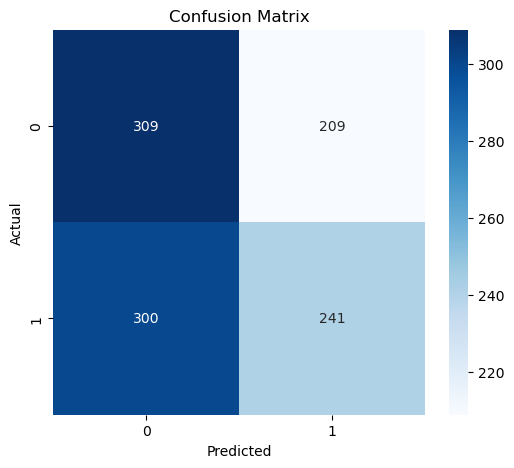

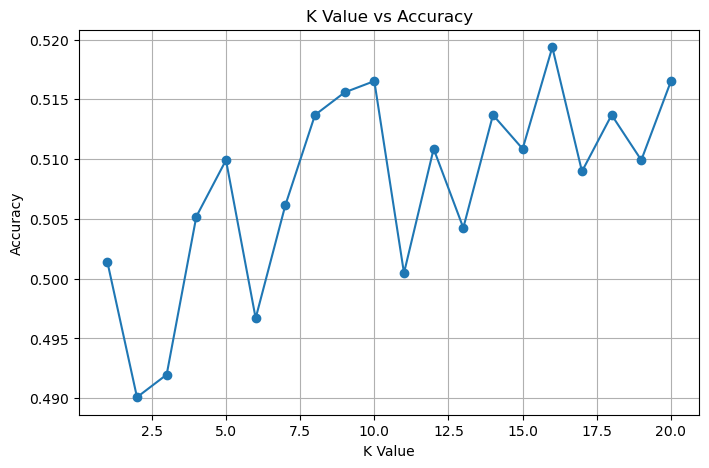

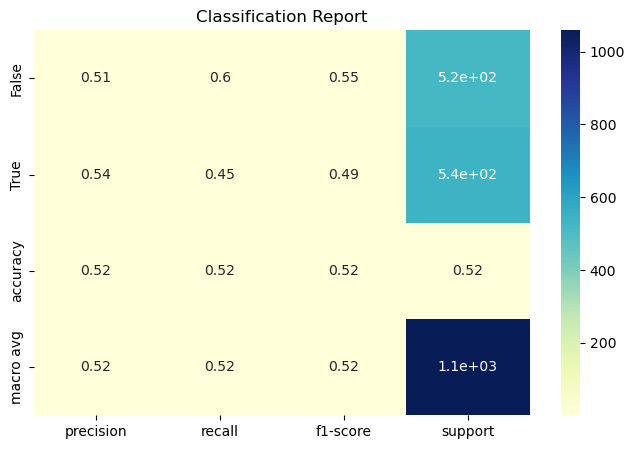

In [2]:
# ==========================================
# Diabetes Prediction using KNN
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv(r"C:\Users\HI\OneDrive\Desktop\Project\diabetes_prediction_india.csv")

# ==========================================
# Handle Missing Values
# ==========================================

# Fill numerical missing values with median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# ==========================================
# One-Hot Encoding
# ==========================================

df = pd.get_dummies(df, drop_first=True)

# ==========================================
# Features and Target
# ==========================================

target = "Diabetes_Status_Yes"

X = df.drop(target, axis=1)
y = df[target]

# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================
# Find Best K
# ==========================================

accuracy_scores = []

for k in range(1,21):

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    accuracy_scores.append(accuracy_score(y_test,pred))

best_k = accuracy_scores.index(max(accuracy_scores))+1

print("Best K =",best_k)

# ==========================================
# Train Final Model
# ==========================================

knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train,y_train)

# ==========================================
# Prediction
# ==========================================

y_pred = knn.predict(X_test)

# ==========================================
# Accuracy
# ==========================================

accuracy = accuracy_score(y_test,y_pred)

print("\nAccuracy :",accuracy)

print("\nClassification Report\n")

print(classification_report(y_test,y_pred))

print("\nConfusion Matrix\n")

print(confusion_matrix(y_test,y_pred))

# ==========================================
# Confusion Matrix
# ==========================================

plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(y_test,y_pred),
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ==========================================
# K vs Accuracy
# ==========================================

plt.figure(figsize=(8,5))

plt.plot(range(1,21),
         accuracy_scores,
         marker='o')

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K Value vs Accuracy")

plt.grid()

plt.show()

# ==========================================
# Classification Report Heatmap
# ==========================================

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,5))

sns.heatmap(report_df.iloc[:-1,:],
            annot=True,
            cmap="YlGnBu")

plt.title("Classification Report")

plt.show()